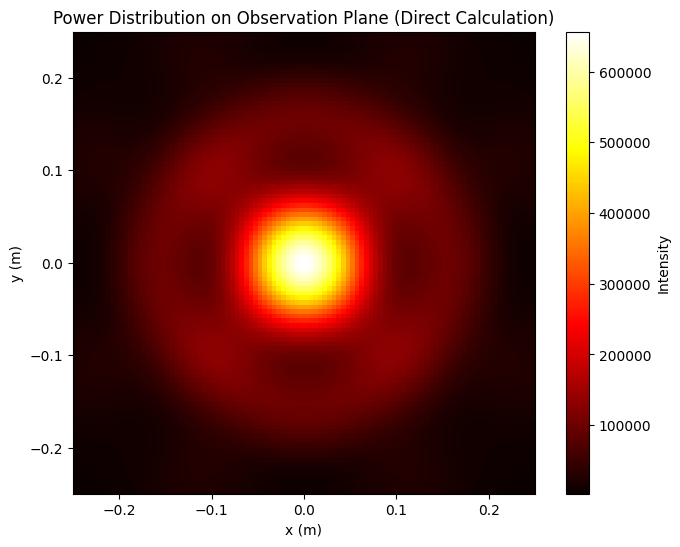

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定数
wavelength = 0.01  # 波長 λ = 1cm
focal_length = 5.0  # 焦点距離 5m
observation_plane = 5  # 観測面までの距離 4m
plate_radius = 1.0/4  # ゾーンプレートの半径 (m)
grid_size = 100  # ゾーンプレートの解像度
obs_grid_size = 100  # 観測平面の解像度

# グリッド設定
x = np.linspace(-plate_radius, plate_radius, grid_size)
y = np.linspace(-plate_radius, plate_radius, grid_size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# ゾーンプレートの振幅分布
zone_pattern = ((R**2 / (2 * focal_length)) % wavelength) < (wavelength / 2)

# 観測平面のグリッド
obs_x = np.linspace(-plate_radius, plate_radius, obs_grid_size)
obs_y = np.linspace(-plate_radius, plate_radius, obs_grid_size)
obs_X, obs_Y = np.meshgrid(obs_x, obs_y)

# 観測平面での振幅計算
k = 2 * np.pi / wavelength  # 波数
field = np.zeros((obs_grid_size, obs_grid_size), dtype=complex)

# ゾーンプレートの各点から観測平面への波の寄与を計算
for i in range(grid_size):
    for j in range(grid_size):
        if zone_pattern[i, j]:  # ゾーンが光を通す場合
            # ゾーンプレート上の座標
            source_x = X[i, j]
            source_y = Y[i, j]
            source_z = 0  # ゾーンプレート面はz=0

            # 観測平面までの距離
            r = np.sqrt((obs_X - source_x)**2 + (obs_Y - source_y)**2 + observation_plane**2)

            # 振幅寄与を累積
            field += np.exp(1j * k * r) / r

# パワー分布（強度）
intensity = np.abs(field)**2

# パワー分布の描画
plt.figure(figsize=(8, 6))
plt.imshow(intensity, extent=(-plate_radius, plate_radius, -plate_radius, plate_radius), cmap='hot', origin='upper')
plt.colorbar(label="Intensity")
plt.title("Power Distribution on Observation Plane (Direct Calculation)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()


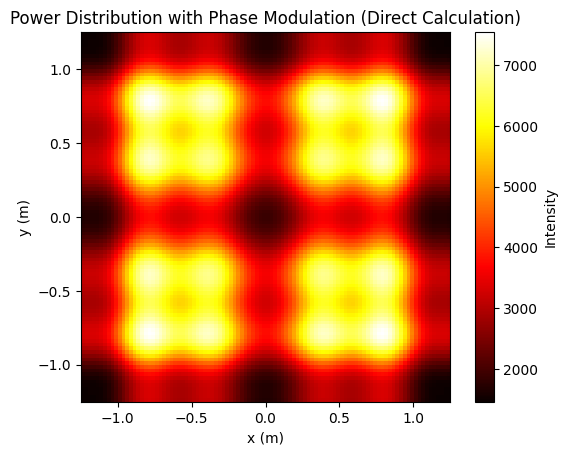

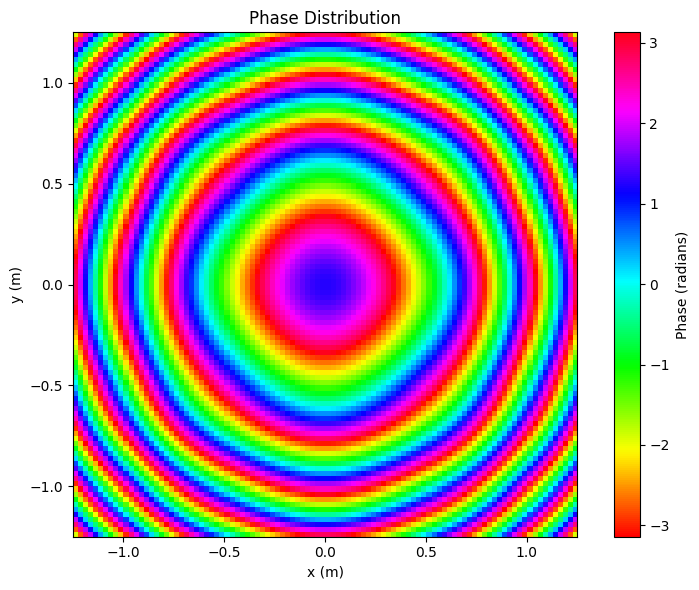

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定数
wavelength = 0.01  # 波長 λ = 1cm
focal_length = 5  # 焦点距離 5m

plate_radius = 0.25  # ゾーンプレートの半径 (m)
plate_grid_size = 100  # ゾーンプレートの解像度

observation_plane = 20 # 観測面 z = 4m
observation_radius = plate_radius*5
observation_grid_size = 100


k = 2 * np.pi / wavelength  # 波数

# ゾーンプレートのグリッド
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# 位相変調（フレネル位相）
phase = k * (np.sqrt(X**2 + Y**2 + focal_length**2) - focal_length)

# ゾーンプレートの振幅分布（位相変調を振幅に適用）
#zone_amplitude = np.exp(1j * phase * (-1))
#zone_amplitude = np.exp(1j * phase * (-0.5))
#zone_amplitude = np.exp(1j * phase * (0))
#zone_amplitude = np.exp(1j * phase * (1))
#zone_amplitude = np.exp(1j * phase * (2))

s_param=1.3
zone_amplitude = np.exp(1j * phase * (s_param))

# 観測平面のグリッド

obs_x = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_y = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_X, obs_Y = np.meshgrid(obs_x, obs_y)

# 観測平面での振幅計算
field = np.zeros_like(obs_X, dtype=complex)

# ゾーンプレートの各点から観測平面への波の寄与を計算
for i in range(plate_grid_size):
    for j in range(plate_grid_size):
        # ゾーンプレート上の座標
        source_x = X[i, j]
        source_y = Y[i, j]
        source_z = 0  # ゾーンプレート面は z=0

        # 観測平面までの距離
        r = np.sqrt((obs_X - source_x)**2 + (obs_Y - source_y)**2 + observation_plane**2)

        # 観測平面での振幅累積
        field += zone_amplitude[i, j] * np.exp(1j * k * r) / r

# パワー分布（強度）
intensity = np.abs(field)**2

# パワー分布の描画
plt.imshow(intensity, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hot', origin='upper')
plt.colorbar(label="Intensity")
plt.title("Power Distribution with Phase Modulation (Direct Calculation)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()


# 位相
phase_image = np.angle(field)  # Calculate the phase of the field


#  Phase
plt.figure(figsize=(8, 6))
plt.imshow(phase_image, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hsv', origin='upper')  # Use 'hsv' or another suitable colormap
plt.colorbar(label="Phase (radians)")
plt.title("Phase Distribution")
plt.xlabel("x (m)")
plt.ylabel("y (m)")

plt.tight_layout()  # Adjust spacing between subplots
plt.show()


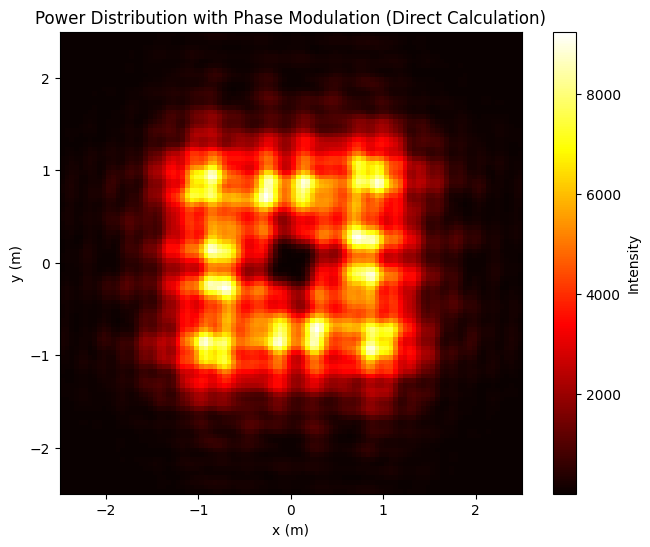

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定数
wavelength = 0.01  # 波長 λ = 1cm
focal_length = 10  # 焦点距離 5m

plate_radius = 0.25  # ゾーンプレートの半径 (m)
plate_grid_size = 100  # ゾーンプレートの解像度

observation_plane = 10 # 観測面 z = 4m
observation_radius = plate_radius*10
observation_grid_size = 100


k = 2 * np.pi / wavelength  # 波数

# ゾーンプレートのグリッド
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)


# 位相変調（フレネル位相）
phase = k * (np.sqrt(X**2 + Y**2 + focal_length**2) - focal_length)
s_param=5
phase *= (s_param)

# 条件に基づいて位相シフトを追加
#phase[ (X >= 0) & (Y >= 0) | (X < 0) & (Y < 0) ] += np.pi*1

#phase[ (X >= 0) & (Y >= 0)] += np.pi*0/2
#phase[ (X < 0) & (Y >= 0)] += np.pi*1/2
#phase[ (X < 0) & (Y < 0) ] += np.pi*2/2
#phase[ (X >= 0) & (Y < 0)] += np.pi*3/2

# Convert Cartesian coordinates to polar
rho = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)

# Discretize the angle into 45-degree increments
angle_step = np.pi / 8 # 45 degrees in radians
phi_quantized = np.round(phi / angle_step)  # Round to the nearest increment

# Calculate discrete phase shifts based on quantized angle
phase_shift = phi_quantized * angle_step

# Apply phase shifts to the original phase
phase += phase_shift




# ゾーンプレートの振幅分布（位相変調を振幅に適用）
#zone_amplitude = np.exp(1j * phase * (-1))
#zone_amplitude = np.exp(1j * phase * (-0.5))
#zone_amplitude = np.exp(1j * phase * (0))
#zone_amplitude = np.exp(1j * phase * (1))
#zone_amplitude = np.exp(1j * phase * (2))

zone_amplitude = np.exp(1j * phase)
#zone_amplitude[ (X >= 0) & (Y >= 0) | (X < 0) & (Y < 0) ] = 0

# 観測平面のグリッド

obs_x = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_y = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_X, obs_Y = np.meshgrid(obs_x, obs_y)

# 観測平面での振幅計算
field = np.zeros_like(obs_X, dtype=complex)

# ゾーンプレートの各点から観測平面への波の寄与を計算
for i in range(plate_grid_size):
    for j in range(plate_grid_size):
        # ゾーンプレート上の座標
        source_x = X[i, j]
        source_y = Y[i, j]
        source_z = 0  # ゾーンプレート面は z=0

        # 観測平面までの距離
        r = np.sqrt((obs_X - source_x)**2 + (obs_Y - source_y)**2 + observation_plane**2)

        # 観測平面での振幅累積
        field += zone_amplitude[i, j] * np.exp(1j * k * r) / r

# パワー分布（強度）
intensity = np.abs(field)**2

# パワー分布の描画
plt.figure(figsize=(8, 6))
plt.imshow(intensity, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hot', origin='lower')

plt.colorbar(label="Intensity")
plt.title("Power Distribution with Phase Modulation (Direct Calculation)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()

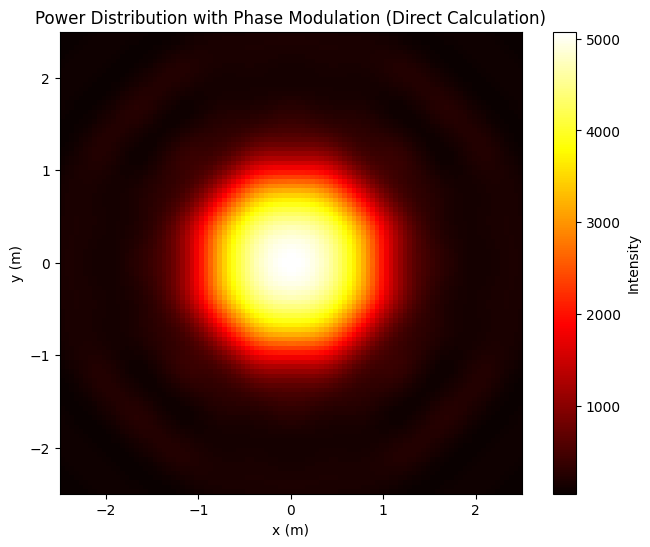

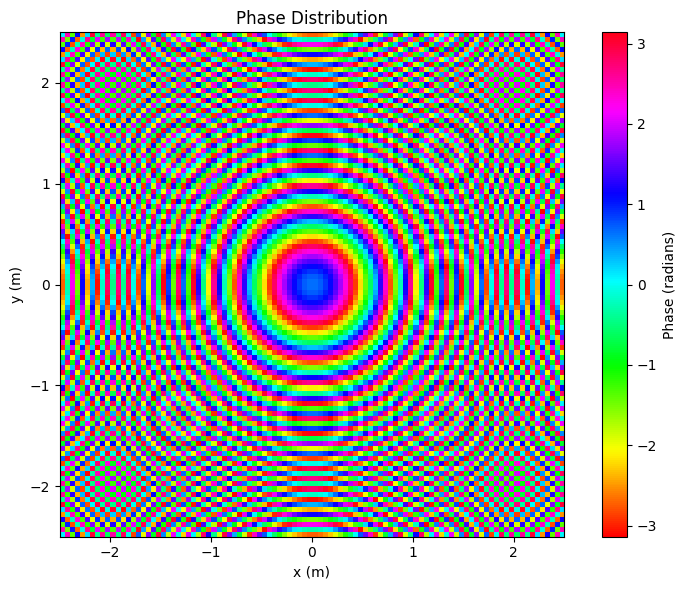

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0  # j1: 第一種ベッセル関数

# 定数
wavelength = 0.01  # 波長 λ = 1cm
focal_length = 5  # 焦点距離 5m

plate_radius = 0.25  # ゾーンプレートの半径 (m)
plate_grid_size = 100  # ゾーンプレートの解像度

observation_plane = 20 # 観測面 z = 4m
observation_radius = plate_radius*10
observation_grid_size = 100


k = 2 * np.pi / wavelength  # 波数

# ゾーンプレートのグリッド
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
r = np.sqrt(X**2 + Y**2)


# 位相変調（フレネル位相）
phase = k * (np.sqrt(X**2 + Y**2 + focal_length**2) - focal_length)
#s_param=5
s_param=2
phase *= (s_param)



# 標準偏差
#sigma = 0.25*0.6
sigma = 0.25*1
# ガウス関数を計算
gaussian_window = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
#zone_amplitude = np.exp(1j * phase) * gaussian_window

#zone_amplitude = np.exp(1j * phase)



a=0.25*1
# ベッセル関数を計算
# r: 原点からの距離,  a: パラメータ (例: plate_radius)
bessel_window = j0(np.pi * r/a) / (np.pi * r/a)

# zone_amplitude にベッセル関数を掛け合わせる
zone_amplitude = np.exp(1j * phase) * bessel_window




# 観測平面のグリッド

obs_x = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_y = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_X, obs_Y = np.meshgrid(obs_x, obs_y)

# 観測平面での振幅計算
field = np.zeros_like(obs_X, dtype=complex)

# ゾーンプレートの各点から観測平面への波の寄与を計算
for i in range(plate_grid_size):
    for j in range(plate_grid_size):
        # ゾーンプレート上の座標
        source_x = X[i, j]
        source_y = Y[i, j]
        source_z = 0  # ゾーンプレート面は z=0

        # 観測平面までの距離
        r = np.sqrt((obs_X - source_x)**2 + (obs_Y - source_y)**2 + observation_plane**2)

        # 観測平面での振幅累積
        field += zone_amplitude[i, j] * np.exp(1j * k * r) / r

# パワー分布（強度）
intensity = np.abs(field)**2

# パワー分布の描画
plt.figure(figsize=(8, 6))
plt.imshow(intensity, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hot', origin='lower')

plt.colorbar(label="Intensity")
plt.title("Power Distribution with Phase Modulation (Direct Calculation)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()


# 位相
phase_image = np.angle(field)  # Calculate the phase of the field


#  Phase
plt.figure(figsize=(8, 6))
plt.imshow(phase_image, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hsv', origin='upper')  # Use 'hsv' or another suitable colormap
plt.colorbar(label="Phase (radians)")
plt.title("Phase Distribution")
plt.xlabel("x (m)")
plt.ylabel("y (m)")

plt.tight_layout()  # Adjust spacing between subplots
plt.show()



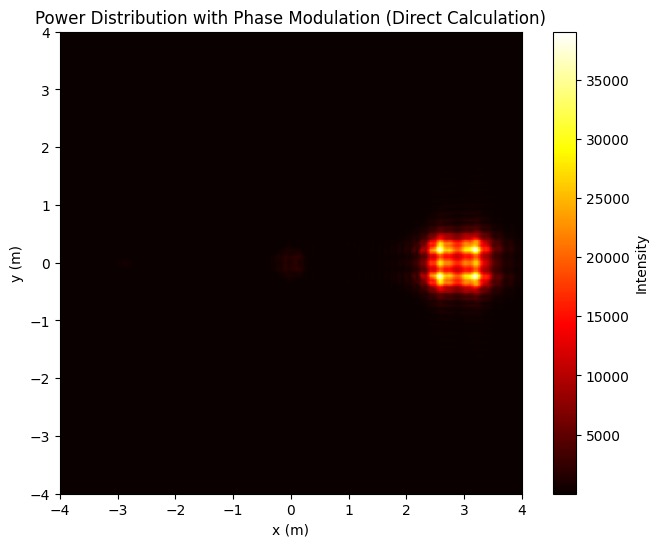

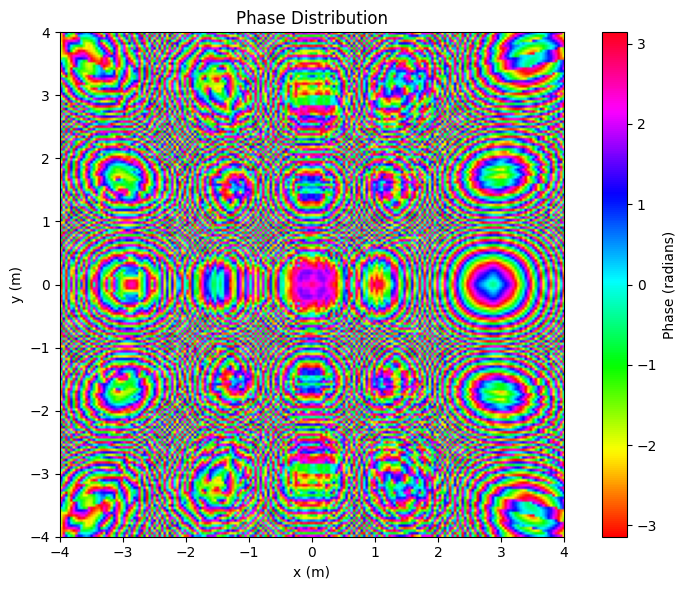

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0  # j1: 第一種ベッセル関数

# 定数
wavelength = 0.01  # 波長 λ = 1cm
focal_length = 5  # 焦点距離 5m

plate_radius = 0.25  # ゾーンプレートの半径 (m)
plate_grid_size = 100  # ゾーンプレートの解像度

observation_plane = 5 # 観測面 z = 4m
observation_radius = plate_radius*16
observation_grid_size = 100*2


k = 2 * np.pi / wavelength  # 波数

# ゾーンプレートのグリッド
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
r = np.sqrt(X**2 + Y**2)


# 位相変調（フレネル位相）
phase = k * (np.sqrt(X**2 + Y**2 + focal_length**2) - focal_length)
d=0.005
fai = -X*k*np.sin(-np.pi/6*1)
#s_param=5
s_param=1#0.5
phase *= (s_param)



# 標準偏差
#sigma = 0.25*0.6
sigma = 0.25*1
# ガウス関数を計算
gaussian_window = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
#zone_amplitude = np.exp(1j * phase) * gaussian_window

#zone_amplitude = np.exp(1j * phase)
#zone_amplitude = np.exp(1j * (phase + fai))
zone_amplitude = np.exp(1j * (phase + fai)) * modified_f_phase

a=0.25*1
# ベッセル関数を計算
# r: 原点からの距離,  a: パラメータ (例: plate_radius)
bessel_window = j0(np.pi * r/a) / (np.pi * r/a)

# zone_amplitude にベッセル関数を掛け合わせる
#zone_amplitude = np.exp(1j * phase) * bessel_window




# 観測平面のグリッド

obs_x = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_y = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_X, obs_Y = np.meshgrid(obs_x, obs_y)

# 観測平面での振幅計算
field = np.zeros_like(obs_X, dtype=complex)

# ゾーンプレートの各点から観測平面への波の寄与を計算
for i in range(plate_grid_size):
    for j in range(plate_grid_size):
        # ゾーンプレート上の座標
        source_x = X[i, j]
        source_y = Y[i, j]
        source_z = 0  # ゾーンプレート面は z=0

        # 観測平面までの距離
        r = np.sqrt((obs_X - source_x)**2 + (obs_Y - source_y)**2 + observation_plane**2)

        # 観測平面での振幅累積
        field += zone_amplitude[i, j] * np.exp(1j * k * r) / r

# パワー分布（強度）
intensity = np.abs(field)**2

# パワー分布の描画
plt.figure(figsize=(8, 6))
plt.imshow(intensity, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hot', origin='lower')

plt.colorbar(label="Intensity")
plt.title("Power Distribution with Phase Modulation (Direct Calculation)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()


# 位相
phase_image = np.angle(field)  # Calculate the phase of the field


#  Phase
plt.figure(figsize=(8, 6))
plt.imshow(phase_image, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hsv', origin='upper')  # Use 'hsv' or another suitable colormap
plt.colorbar(label="Phase (radians)")
plt.title("Phase Distribution")
plt.xlabel("x (m)")
plt.ylabel("y (m)")

plt.tight_layout()  # Adjust spacing between subplots
plt.show()



<ipython-input-33-4ee99c067722>:91: ComplexWarning: Casting complex values to real discards the imaginary part
  modified_f_phase[i, j] = modified_f(np.mod((phase[i, j] + fai[i, j]), 2*np.pi))


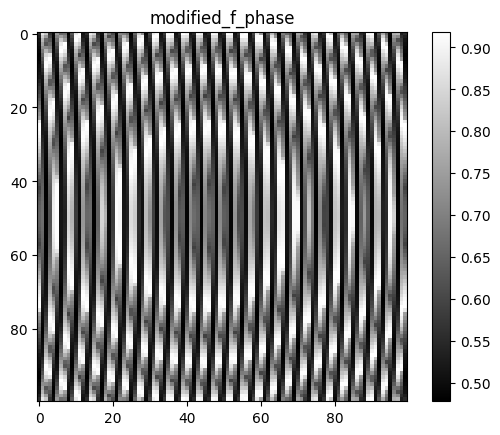

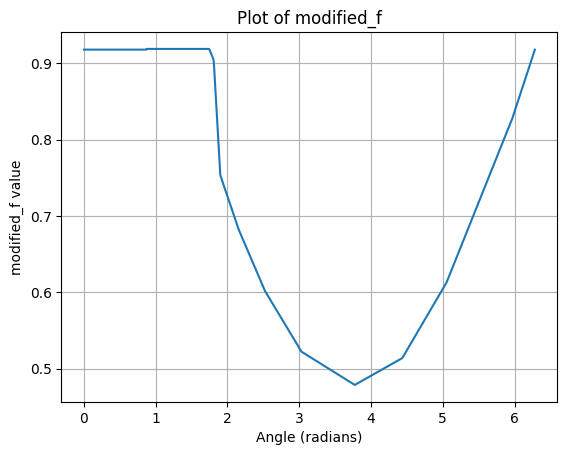

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0  # j1: 第一種ベッセル関数
from scipy.interpolate import interp1d

# 定数
wavelength = 0.01  # 波長 λ = 1cm
focal_length = 5  # 焦点距離 5m

plate_radius = 0.25  # ゾーンプレートの半径 (m)
plate_grid_size = 100  # ゾーンプレートの解像度

observation_plane = 5 # 観測面 z = 4m
observation_radius = plate_radius*16
observation_grid_size = 100*2


k = 2 * np.pi / wavelength  # 波数

# ゾーンプレートのグリッド
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
r = np.sqrt(X**2 + Y**2)


# 位相変調（フレネル位相）
phase = k * (np.sqrt(X**2 + Y**2 + focal_length**2) - focal_length)
d=0.005
fai = -X*k*np.sin(-np.pi/6)*1
#s_param=5
s_param=1#0.5
phase *= (s_param)



# 標準偏差
#sigma = 0.25*0.6
sigma = 0.25*1
# ガウス関数を計算
gaussian_window = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
#zone_amplitude = np.exp(1j * phase) * gaussian_window

#zone_amplitude = np.exp(1j * phase)
zone_amplitude = np.exp(1j * (phase + fai))

# --- ここから ---
# データをNumPy配列として準備する
angles_deg = np.array([360.000000000000, 341.649279999991, 289.489819999984, 254.177619999980, 216.221519999990, 173.556819999973, 144.487999999987, 123.357709999989, 108.858109999977, 103.586299999986, 101.752379999991, 100.762539999978])
values = np.array([0.917748113, 0.825975185, 0.612721331, 0.513770306, 0.478532017, 0.522206773, 0.601731851, 0.682763035, 0.753176914, 0.904085492, 0.911333846, 0.915475023])

# 角度をラジアンに変換
angles_rad = np.deg2rad(angles_deg)

# 線形補間を行う
f = interp1d(angles_rad, values, kind='linear', fill_value="extrapolate")

# 0～100度までは1にする、fの出力を0～1にクリップ
sftx=0#65
def modified_f(x_rad):  # 入力をラジアンで受け取る
    if 0 <= x_rad <= np.deg2rad(50):
#       return 0  # 単一の値を返す
        return np.clip(f(np.deg2rad(360)), 0, 1)*np.exp(1j*(-1*x_rad+np.deg2rad(360)))#1  # 単一の値を返す
#        return np.clip(f(x_rad + np.deg2rad(310)), 0, 1)*np.exp(1j*np.deg2rad(310))  # 単一の値を返す
    if np.deg2rad(50) < x_rad <= np.deg2rad(100):
#       return 0  # 単一の値を返す
        return np.clip(f(np.deg2rad(100)), 0, 1)*np.exp(1j*(-1*x_rad+np.deg2rad(100)))#1  # 単一の値を返す
#        return np.clip(f(x_rad + np.deg2rad(50)), 0, 1)*np.exp(1j*np.deg2rad(50))  # 単一の値を返す
    if np.deg2rad(215-sftx) <= x_rad < np.deg2rad(215):
        return np.clip(f(np.deg2rad(215-sftx)), 0, 1)*np.exp(1j*(-1*x_rad+np.deg2rad(215-sftx)))#1  # 単一の値を返す
    if np.deg2rad(215) <= x_rad < np.deg2rad(215+sftx):
        return np.clip(f(np.deg2rad(215+sftx)), 0, 1)*np.exp(1j*(-1*x_rad+np.deg2rad(215+sftx)))#1  # 単一の値を返す
    else:
        return np.clip(f(x_rad), 0, 1) # fの出力を0～1にクリップ
#        return f(x_rad)  # 単一の値を返す

# modified_f をベクトル化
#modified_f_vectorized = np.vectorize(modified_f)
# phase 配列に modified_f を適用
#modified_f_phase = modified_f_vectorized(np.mod((phase+fai), 2*np.pi) )
#modified_f_phase = np.mod((phase+fai), 2*np.pi)
#modified_f_phase = modified_f(np.mod((phase+fai)*180/np.pi, 360) )
# --- ここまで ---

# Create an empty array to store the results
modified_f_phase = np.zeros_like(phase, dtype=float)  # Matching shape and data type

# Iterate over the phase array and apply modified_f
for i in range(phase.shape[0]):  # Loop over rows
    for j in range(phase.shape[1]):  # Loop over columns
        modified_f_phase[i, j] = modified_f(np.mod((phase[i, j] + fai[i, j]), 2*np.pi))



# modified_f_phase を画像表示
plt.imshow(modified_f_phase, cmap='gray') # cmap='gray' でグレースケールで表示
plt.colorbar() # カラーバーを表示
plt.title("modified_f_phase") # タイトルを設定
plt.show() # 画像を表示



# プロット用のx軸データ (ラジアン)
x_rad = np.linspace(0, 2*np.pi, 1000)

# modified_fを適用してy軸データを取得
y = [np.abs(modified_f(rad)) for rad in x_rad]

# プロット (x軸をラジアンのままにする)
plt.plot(x_rad, y)
plt.xlabel("Angle (radians)")  # x軸ラベルをラジアンに変更
plt.ylabel("modified_f value")
plt.title("Plot of modified_f")
plt.grid(True)
plt.show()

In [ ]:
modified_f_phase

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

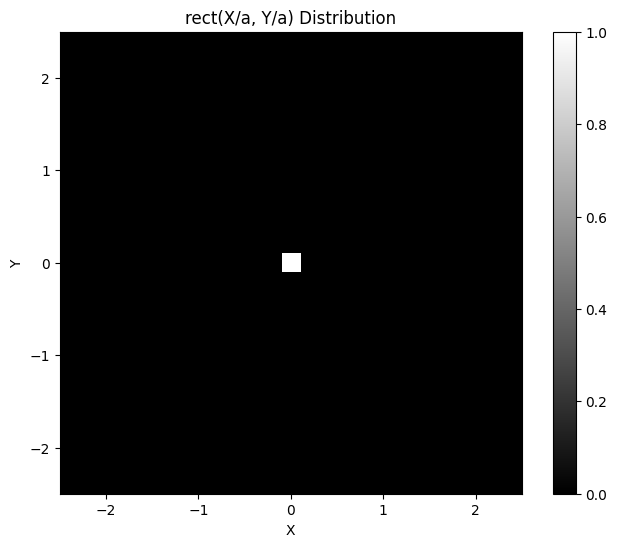

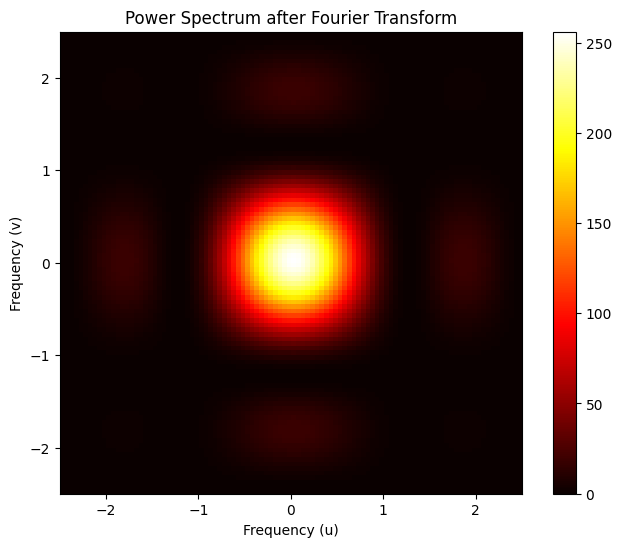

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift

# パラメータ設定
a = 0.2  # rect関数の幅と高さ
grid_size = 100  # グリッドサイズ
observation_radius=2.5

# グリッド生成
x = np.linspace(-observation_radius, observation_radius, grid_size)
y = np.linspace(-observation_radius, observation_radius, grid_size)
X, Y = np.meshgrid(x, y)

# rect関数の分布を生成
rect_distribution = ((np.abs(X/a) <= 0.5) & (np.abs(Y/a) <= 0.5)).astype(int)

# フーリエ変換
fourier_transform = fftshift(fft2(rect_distribution))

# パワースペクトルを計算
power_spectrum = np.abs(fourier_transform)**2

# rect関数の分布を可視化
plt.figure(figsize=(8, 6))
plt.imshow(rect_distribution, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius),  cmap='gray', origin='lower')
plt.title("rect(X/a, Y/a) Distribution")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar()
plt.show()

# フーリエ変換後のパワースペクトルを可視化
plt.figure(figsize=(8, 6))
plt.imshow(power_spectrum, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hot', origin='lower')  # extentは省略
plt.title("Power Spectrum after Fourier Transform")
plt.xlabel("Frequency (u)")
plt.ylabel("Frequency (v)")
plt.colorbar()
plt.show()

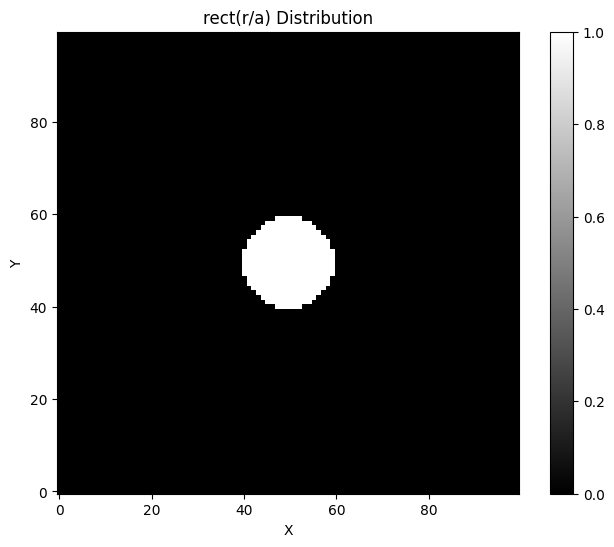

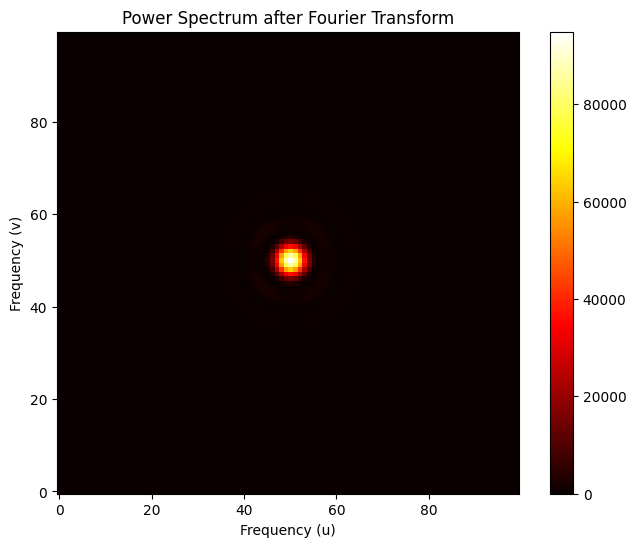

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift

# パラメータ設定
a = 20  # rect関数の半径
grid_size = 100  # グリッドサイズ
d=100

# グリッド生成
x = np.linspace(-d/2, d/2, grid_size)
y = np.linspace(-d/2, d/2, grid_size)
X, Y = np.meshgrid(x, y)
r = np.sqrt(X**2 + Y**2)  # 原点からの距離

# rect(r/a) の分布を生成
rect_distribution = (r <= a/2).astype(int)

# フーリエ変換
fourier_transform = fftshift(fft2(rect_distribution))

# パワースペクトルを計算
power_spectrum = np.abs(fourier_transform)**2

# rect(r/a) の分布を可視化
plt.figure(figsize=(8, 6))
plt.imshow(rect_distribution, cmap='gray', origin='lower')
plt.title("rect(r/a) Distribution")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar()
plt.show()

# フーリエ変換後のパワースペクトルを可視化
plt.figure(figsize=(8, 6))
plt.imshow(power_spectrum, cmap='hot', origin='lower')  # extentは省略
plt.title("Power Spectrum after Fourier Transform")
plt.xlabel("Frequency (u)")
plt.ylabel("Frequency (v)")
plt.colorbar()
plt.show()

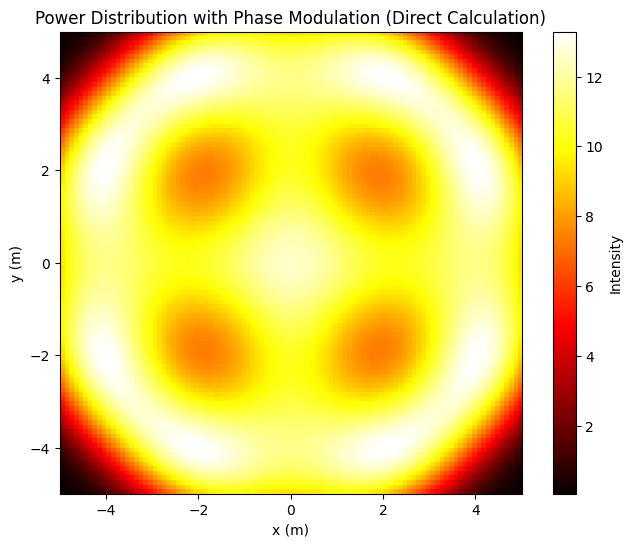

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1  # j1: 第一種ベッセル関数

# 定数
wavelength = 0.01  # 波長 λ = 1cm
focal_length = 5  # 焦点距離 5m

plate_radius = 0.25  # ゾーンプレートの半径 (m)
plate_grid_size = 100  # ゾーンプレートの解像度

observation_plane = 20*5 # 観測面 z = 4m
observation_radius = plate_radius*20
observation_grid_size = 100


k = 2 * np.pi / wavelength  # 波数

# ゾーンプレートのグリッド
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
r = np.sqrt(X**2 + Y**2)


# 位相変調（フレネル位相）
phase = k * (np.sqrt(X**2 + Y**2 + focal_length**2) - focal_length)
s_param=0
phase *= (s_param)



# 標準偏差
#sigma = 0.25*0.6
sigma = 0.25*1
# ガウス関数を計算
gaussian_window = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
#zone_amplitude = np.exp(1j * phase) * gaussian_window




a=0.25*50
# ベッセル関数を計算
# r: 原点からの距離,  a: パラメータ (例: plate_radius)
bessel_window = 2* j1(np.pi * a * r) / (np.pi * a * r)

# zone_amplitude にベッセル関数を掛け合わせる
zone_amplitude = np.exp(1j * phase) * bessel_window
#zone_amplitude = np.exp(1j * phase)




# 観測平面のグリッド

obs_x = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_y = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_X, obs_Y = np.meshgrid(obs_x, obs_y)

# 観測平面での振幅計算
field = np.zeros_like(obs_X, dtype=complex)

# ゾーンプレートの各点から観測平面への波の寄与を計算
for i in range(plate_grid_size):
    for j in range(plate_grid_size):
        # ゾーンプレート上の座標
        source_x = X[i, j]
        source_y = Y[i, j]
        source_z = 0  # ゾーンプレート面は z=0

        # 観測平面までの距離
        r = np.sqrt((obs_X - source_x)**2 + (obs_Y - source_y)**2 + observation_plane**2)

        # 観測平面での振幅累積
        field += zone_amplitude[i, j] * np.exp(1j * k * r) / r

# パワー分布（強度）
intensity = np.abs(field)**2

# パワー分布の描画
plt.figure(figsize=(8, 6))
plt.imshow(intensity, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hot', origin='lower')

plt.colorbar(label="Intensity")
plt.title("Power Distribution with Phase Modulation (Direct Calculation)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()

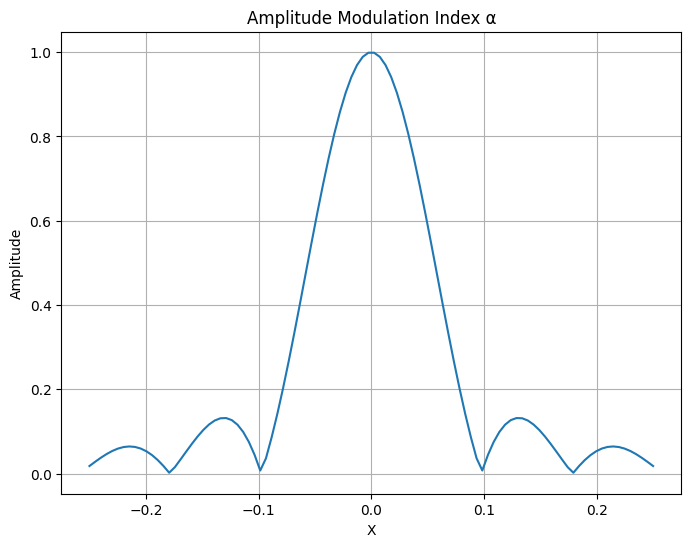

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0
from scipy.special import j1

# パラメータ設定
a = 0.25 * 50  # ベッセル関数のスケールパラメータ
grid_size = 100  # グリッドサイズ

# x軸の範囲を指定 (y=0 とする)
x = np.linspace(-0.25, 0.25, grid_size)
y = np.zeros_like(x)  # y=0
r = np.abs(x)  # 原点からの距離 (x軸上)

# ベッセル関数を計算
#bessel_window = j0(np.pi * r / a)  # J0(πr/a) を計算
#bessel_window = 2*np.pi*(a/2)**2* j1(np.pi * a * r) / (np.pi * a * r)  #j0(πr/a) / (πr/a)
bessel_window = 2* j1(np.pi * a * r) / (np.pi * a * r)
#bessel_window = np.abs(bessel_window)**(1/2)
bessel_window = np.abs(bessel_window)

#bessel_window = 2* j0(np.pi * a * r) / (np.pi * a * r)
# r=0 でのゼロ除算を回避 (J0(πr/a) / (πr/a) の場合)
#bessel_window[r == 0] = 1  # r=0 の場合、値を1に設定

# 二次元グラフ描画
plt.figure(figsize=(8, 6))
plt.plot(x, bessel_window)
plt.title("Amplitude Modulation Index α")
plt.xlabel("X")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

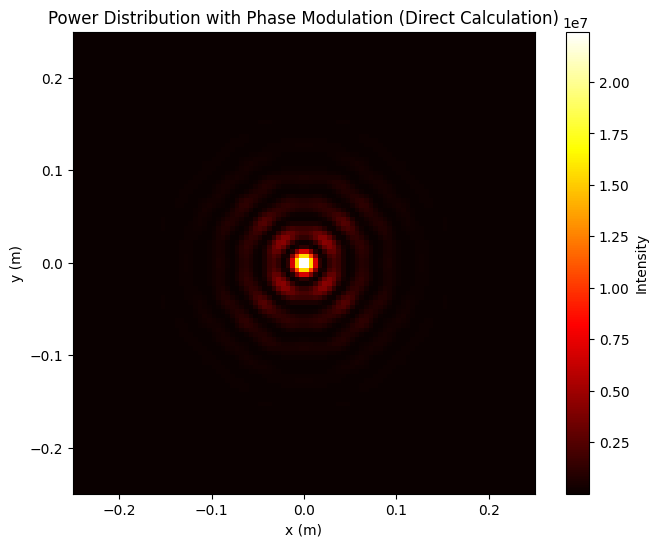

In [ ]:
｝import numpy as np
import matplotlib.pyplot as plt

# 定数
wavelength = 0.01  # 波長 λ = 1cm
focal_length = 10  # 焦点距離 5m

plate_radius = 0.25  # ゾーンプレートの半径 (m)
plate_grid_size = int(100 )  # ゾーンプレートの解像度

observation_plane = 1 # 観測面 z = 4m
observation_radius = plate_radius*1
observation_grid_size = 100


k = 2 * np.pi / wavelength  # 波数

# ゾーンプレートのグリッド
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# 位相変調（フレネル位相）
#phase = k * (np.sqrt(X**2 + Y**2 + focal_length**2) - focal_length)

alpha=0.1736
phase = -1 * k * (np.sqrt(X**2 + Y**2)*alpha )

# ゾーンプレートの振幅分布（位相変調を振幅に適用）
#zone_amplitude = np.exp(1j * phase * (-1))
#zone_amplitude = np.exp(1j * phase * (-0.5))
#zone_amplitude = np.exp(1j * phase * (0))
#zone_amplitude = np.exp(1j * phase * (1))
#zone_amplitude = np.exp(1j * phase * (2))

s_param=1
zone_amplitude = np.exp(1j * phase * (s_param))

# 観測平面のグリッド

obs_x = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_y = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_X, obs_Y = np.meshgrid(obs_x, obs_y)

# 観測平面での振幅計算
field = np.zeros_like(obs_X, dtype=complex)

# ゾーンプレートの各点から観測平面への波の寄与を計算
for i in range(plate_grid_size):
    for j in range(plate_grid_size):
        # ゾーンプレート上の座標
        source_x = X[i, j]
        source_y = Y[i, j]
        source_z = 0  # ゾーンプレート面は z=0

        # 観測平面までの距離
        r = np.sqrt((obs_X - source_x)**2 + (obs_Y - source_y)**2 + observation_plane**2)

        # 観測平面での振幅累積
        field += zone_amplitude[i, j] * np.exp(1j * k * r) / r

# パワー分布（強度）
intensity = np.abs(field)**2

# パワー分布の描画
plt.figure(figsize=(8, 6))
plt.imshow(intensity, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hot', origin='upper')
plt.colorbar(label="Intensity")
plt.title("Power Distribution with Phase Modulation (Direct Calculation)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()


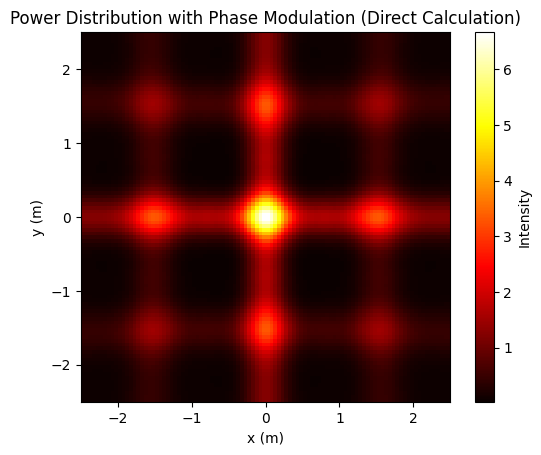

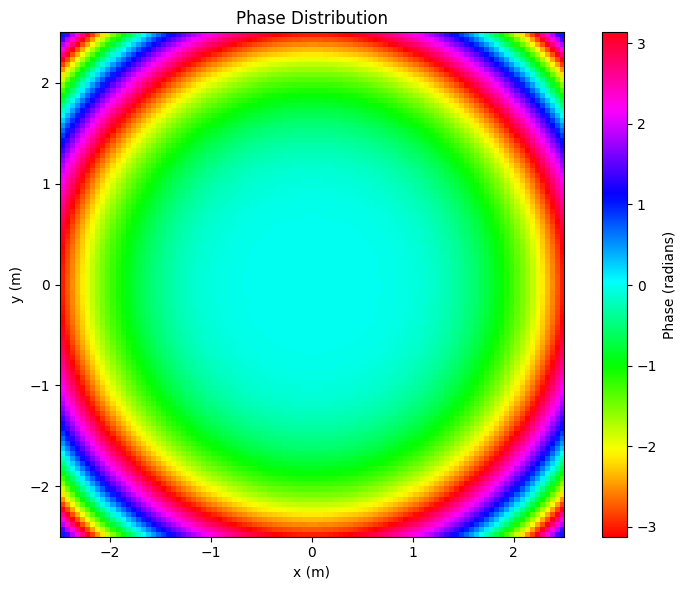

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定数
wavelength = 0.01  # 波長 λ = 1cm
focal_length = 10  # 焦点距離 5m

plate_radius = 0.25  # ゾーンプレートの半径 (m)
plate_grid_size = 100  # ゾーンプレートの解像度

observation_plane = 10 # 観測面 z = 4m
observation_radius = plate_radius*10
observation_grid_size = 100


k = 2 * np.pi / wavelength  # 波数

# ゾーンプレートのグリッド
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)


# Initialize the mask with zeros, same shape as X.
mask = np.zeros_like(X, dtype=int)
# Set the mask to 1 where X is in the range 10 to 15 or -10 to -15.
mask[(X >= plate_radius*0.8) & (X <=plate_radius*0.9)] = 1
mask[(X >= -1*plate_radius*0.9) & (X <= -1*plate_radius*0.8)] = 1
#mask[R <= plate_radius * 0.25] = 1



# 位相変調（フレネル位相）

sa=-1
sb=-1

phase = k * (np.sqrt(sa*X**2 + sb*Y**2 + focal_length**2) - focal_length)

# ゾーンプレートの振幅分布（位相変調を振幅に適用）
#zone_amplitude = np.exp(1j * phase * (-1))
#zone_amplitude = np.exp(1j * phase * (-0.5))
#zone_amplitude = np.exp(1j * phase * (0))
#zone_amplitude = np.exp(1j * phase * (1))
#zone_amplitude = np.exp(1j * phase * (2))

#s_param=2
#zone_amplitude = np.exp(1j * phase * (s_param))
#zone_amplitude = np.exp(1j * phase)
#zone_amplitude = np.exp(1j * phase)*mask

zone_amplitude = np.exp(1j * phase)*mask2

# 観測平面のグリッド

obs_x = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_y = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_X, obs_Y = np.meshgrid(obs_x, obs_y)

# 観測平面での振幅計算
field = np.zeros_like(obs_X, dtype=complex)

# ゾーンプレートの各点から観測平面への波の寄与を計算
for i in range(plate_grid_size):
    for j in range(plate_grid_size):
        # ゾーンプレート上の座標
        source_x = X[i, j]
        source_y = Y[i, j]
        source_z = 0  # ゾーンプレート面は z=0

        # 観測平面までの距離
        r = np.sqrt((obs_X - source_x)**2 + (obs_Y - source_y)**2 + observation_plane**2)

        # 観測平面での振幅累積
        field += zone_amplitude[i, j] * np.exp(1j * k * r) / r

# パワー分布（強度）
intensity = np.abs(field)**2

# パワー分布の描画
plt.imshow(intensity, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hot', origin='upper')
plt.colorbar(label="Intensity")
plt.title("Power Distribution with Phase Modulation (Direct Calculation)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()


# 位相

r2=(obs_X**2 + obs_Y**2)

#phase_image = np.angle(field)  # Calculate the phase of the field
phase_image = np.angle(field * np.exp(-1j * k * r2/(2*observation_plane)))  # Calculate the phase of the field

#  Phase
plt.figure(figsize=(8, 6))
plt.imshow(phase_image, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hsv', origin='upper')  # Use 'hsv' or another suitable colormap
plt.colorbar(label="Phase (radians)")
plt.title("Phase Distribution")
plt.xlabel("x (m)")
plt.ylabel("y (m)")

plt.tight_layout()  # Adjust spacing between subplots
plt.show()


In [ ]:
mask2

array([[3.46774654e-06, 8.24731521e-07, 1.59521524e-08, ...,
        1.59521524e-08, 8.24731521e-07, 3.46774654e-06],
       [7.69674104e-07, 1.83051007e-07, 3.54061593e-09, ...,
        3.54061593e-09, 1.83051007e-07, 7.69674104e-07],
       [1.41806783e-08, 3.37257992e-09, 6.52332396e-11, ...,
        6.52332396e-11, 3.37257992e-09, 1.41806783e-08],
       ...,
       [1.41806783e-08, 3.37257992e-09, 6.52332396e-11, ...,
        6.52332396e-11, 3.37257992e-09, 1.41806783e-08],
       [7.69674104e-07, 1.83051007e-07, 3.54061593e-09, ...,
        3.54061593e-09, 1.83051007e-07, 7.69674104e-07],
       [3.46774654e-06, 8.24731521e-07, 1.59521524e-08, ...,
        1.59521524e-08, 8.24731521e-07, 3.46774654e-06]])

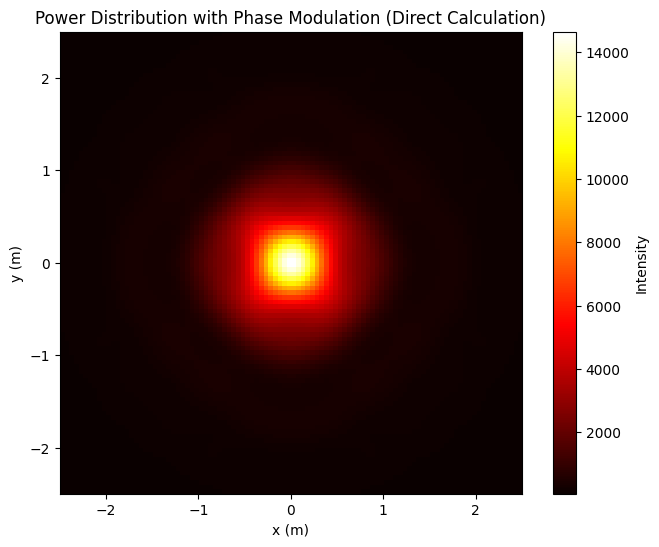

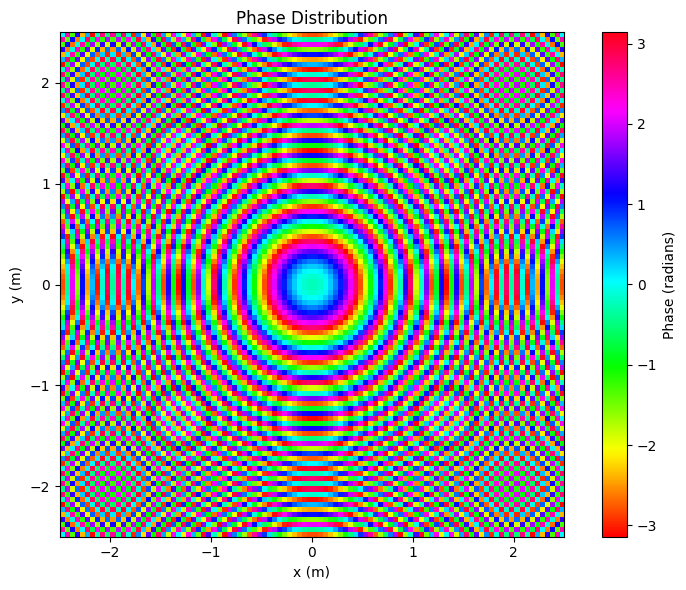

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0  # j1: 第一種ベッセル関数

# 定数
wavelength = 0.01  # 波長 λ = 1cm
focal_length = 5  # 焦点距離 5m

plate_radius = 0.25  # ゾーンプレートの半径 (m)
plate_grid_size = 100  # ゾーンプレートの解像度

observation_plane = 20 # 観測面 z = 4m
observation_radius = plate_radius*10
observation_grid_size = 100


k = 2 * np.pi / wavelength  # 波数

# ゾーンプレートのグリッド
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
r = np.sqrt(X**2 + Y**2)


# 位相変調（フレネル位相）
#phase = k * (np.sqrt(X**2 + Y**2 + focal_length**2) - focal_length)
#s_param=2
#phase *= (s_param)

sa=-1
sb=-1

phase = k * (np.sqrt(sa*X**2 + sb*Y**2 + focal_length**2) - focal_length)


# 標準偏差
#sigma = 0.25*0.6
sigma = 0.25*1
# ガウス関数を計算
gaussian_window = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
#zone_amplitude = np.exp(1j * phase) * gaussian_window

#zone_amplitude = np.exp(1j * phase)



a=0.25*1
# ベッセル関数を計算
# r: 原点からの距離,  a: パラメータ (例: plate_radius)
bessel_window = j0(np.pi * r/a) / (np.pi * r/a)

# zone_amplitude にベッセル関数を掛け合わせる
zone_amplitude = np.exp(1j * phase) * bessel_window




# 観測平面のグリッド

obs_x = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_y = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_X, obs_Y = np.meshgrid(obs_x, obs_y)

# 観測平面での振幅計算
field = np.zeros_like(obs_X, dtype=complex)

# ゾーンプレートの各点から観測平面への波の寄与を計算
for i in range(plate_grid_size):
    for j in range(plate_grid_size):
        # ゾーンプレート上の座標
        source_x = X[i, j]
        source_y = Y[i, j]
        source_z = 0  # ゾーンプレート面は z=0

        # 観測平面までの距離
        r = np.sqrt((obs_X - source_x)**2 + (obs_Y - source_y)**2 + observation_plane**2)

        # 観測平面での振幅累積
        field += zone_amplitude[i, j] * np.exp(1j * k * r) / r

# パワー分布（強度）
intensity = np.abs(field)**2

# パワー分布の描画
plt.figure(figsize=(8, 6))
plt.imshow(intensity, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hot', origin='lower')

plt.colorbar(label="Intensity")
plt.title("Power Distribution with Phase Modulation (Direct Calculation)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()


# 位相
phase_image = np.angle(field)  # Calculate the phase of the field


#  Phase
plt.figure(figsize=(8, 6))
plt.imshow(phase_image, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hsv', origin='upper')  # Use 'hsv' or another suitable colormap
plt.colorbar(label="Phase (radians)")
plt.title("Phase Distribution")
plt.xlabel("x (m)")
plt.ylabel("y (m)")

plt.tight_layout()  # Adjust spacing between subplots
plt.show()


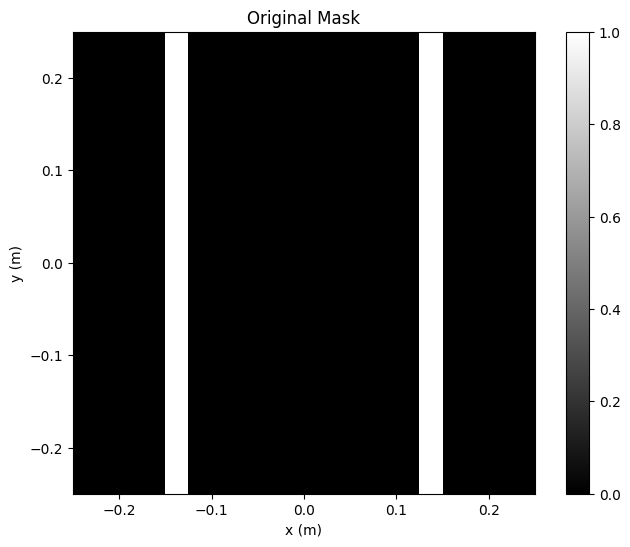

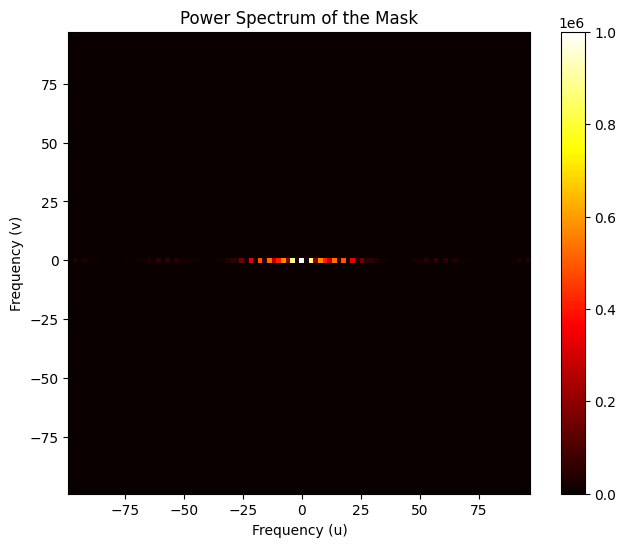

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift, fftfreq

# ゾーンプレートのグリッド
plate_radius = 0.25
plate_grid_size = 100
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# Initialize the mask with zeros, same shape as X.
mask = np.zeros_like(X, dtype=int)
# Set the mask to 1 where X is in the range 10 to 15 or -10 to -15.
mask[(X >= plate_radius*0.5) & (X <=plate_radius*0.6)] = 1
mask[(X >= -1*plate_radius*0.6) & (X <= -1*plate_radius*0.5)] = 1

# Perform the 2D Fourier transform
fourier_transform = fft2(mask)

# Shift the zero frequency component to the center of the spectrum
fourier_transform_shifted = fftshift(fourier_transform)

# Calculate the power spectrum (magnitude squared)
power_spectrum = np.abs(fourier_transform_shifted)**2

# Calculate frequency axes
freq_x = fftshift(fftfreq(plate_grid_size, d=x[1]-x[0]))
freq_y = fftshift(fftfreq(plate_grid_size, d=y[1]-y[0]))


# Display the original mask
plt.figure(figsize=(8, 6))
plt.imshow(mask, cmap='gray', origin='lower', extent=[-plate_radius, plate_radius, -plate_radius, plate_radius])
plt.title("Original Mask")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.show()

# Display the power spectrum
plt.figure(figsize=(8, 6))
plt.imshow(power_spectrum, cmap='hot', origin='lower', extent=[freq_x[0],freq_x[-1],freq_y[0],freq_y[-1]])
plt.title("Power Spectrum of the Mask")
plt.xlabel("Frequency (u)")
plt.ylabel("Frequency (v)")
plt.colorbar()
plt.show()

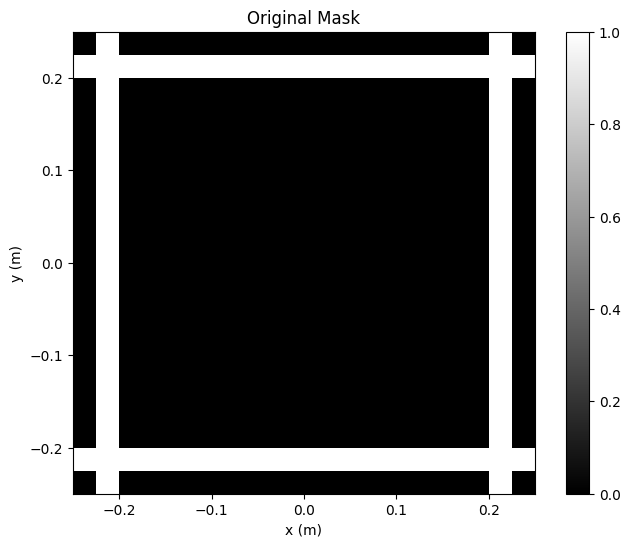

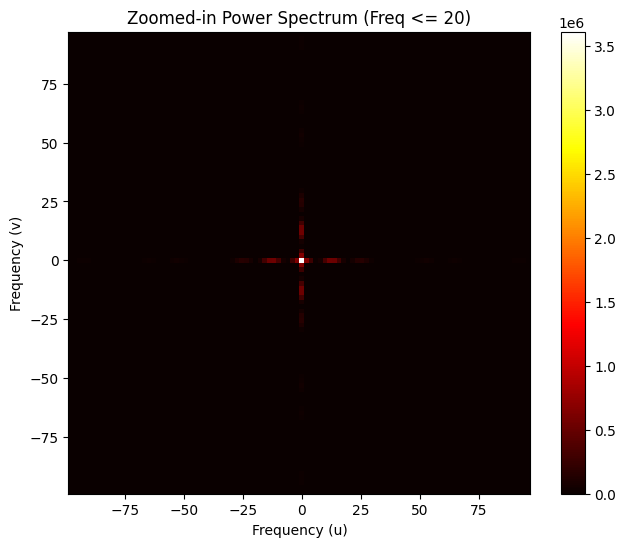

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift, fftfreq

# ゾーンプレートのグリッド
plate_radius = 0.25
plate_grid_size = 100
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# Initialize the mask with zeros, same shape as X.
mask = np.zeros_like(X, dtype=int)
# Set the mask to 1 where X is in the range 10 to 15 or -10 to -15.
mask[(X >= plate_radius*0.8) & (X <=plate_radius*0.9)] = 1
mask[(X >= -1*plate_radius*0.9) & (X <= -1*plate_radius*0.8)] = 1

mask[(Y >= plate_radius*0.8) & (Y <=plate_radius*0.9)] = 1
mask[(Y >= -1*plate_radius*0.9) & (Y <= -1*plate_radius*0.8)] = 1


# Perform the 2D Fourier transform
fourier_transform = fft2(mask)

# Shift the zero frequency component to the center of the spectrum
fourier_transform_shifted = fftshift(fourier_transform)

# Calculate the power spectrum (magnitude squared)
power_spectrum = np.abs(fourier_transform_shifted)**2

# Calculate frequency axes
freq_x = fftshift(fftfreq(plate_grid_size, d=x[1]-x[0]))
freq_y = fftshift(fftfreq(plate_grid_size, d=y[1]-y[0]))

# Create a grid for frequency values
freq_X, freq_Y = np.meshgrid(freq_x, freq_y)

# Create a mask for frequencies <= 20
frequency_mask = (np.abs(freq_X) <= 100) & (np.abs(freq_Y) <= 100)

# Apply the frequency mask to the power spectrum
masked_power_spectrum = np.where(frequency_mask, power_spectrum, 0)


# Find the indices that correspond to the frequency range
indices_x = np.where((freq_x >= -100) & (freq_x <= 100))[0]
indices_y = np.where((freq_y >= -100) & (freq_y <= 100))[0]


# Select the portion of the masked power spectrum
zoomed_power_spectrum = masked_power_spectrum[indices_y[0]:indices_y[-1]+1, indices_x[0]:indices_x[-1]+1]


# Calculate the new extents for the zoomed in plot
zoom_extent = [freq_x[indices_x[0]], freq_x[indices_x[-1]], freq_y[indices_y[0]], freq_y[indices_y[-1]]]

# Display the original mask
plt.figure(figsize=(8, 6))
plt.imshow(mask, cmap='gray', origin='lower', extent=[-plate_radius, plate_radius, -plate_radius, plate_radius])
plt.title("Original Mask")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.show()


# Display the zoomed-in power spectrum
plt.figure(figsize=(8, 6))
plt.imshow(zoomed_power_spectrum, cmap='hot', origin='lower', extent=zoom_extent)
plt.title("Zoomed-in Power Spectrum (Freq <= 20)")
plt.xlabel("Frequency (u)")
plt.ylabel("Frequency (v)")
plt.colorbar()
plt.show()

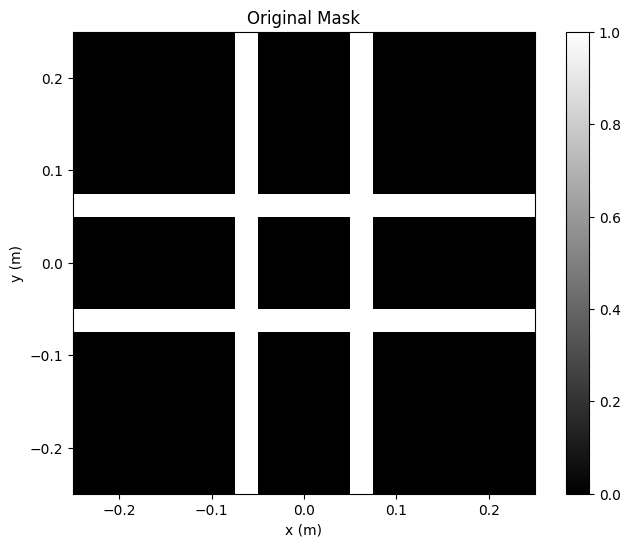

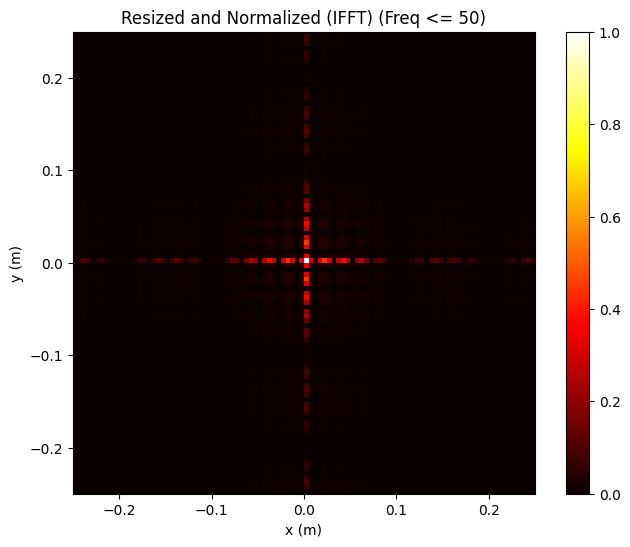

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import ifft2, fftshift, fftfreq
from skimage.transform import resize

# ゾーンプレートのグリッド
plate_radius = 0.25
plate_grid_size = 100
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# Initialize the mask with zeros, same shape as X.
mask = np.zeros_like(X, dtype=int)
# Set the mask to 1 where X is in the range 10 to 15 or -10 to -15.
mask[(X >= plate_radius*0.2) & (X <=plate_radius*0.3)] = 1
mask[(X >= -1*plate_radius*0.3) & (X <= -1*plate_radius*0.2)] = 1

mask[(Y >= plate_radius*0.2) & (Y <=plate_radius*0.3)] = 1
mask[(Y >= -1*plate_radius*0.3) & (Y <= -1*plate_radius*0.2)] = 1


# Perform the 2D Inverse Fourier transform
fourier_transform = ifft2(mask)

# Shift the zero frequency component to the center of the spectrum
fourier_transform_shifted = fftshift(fourier_transform)

# Calculate frequency axes
freq_x = fftshift(fftfreq(plate_grid_size, d=x[1]-x[0]))
freq_y = fftshift(fftfreq(plate_grid_size, d=y[1]-y[0]))

# Create a grid for frequency values
freq_X, freq_Y = np.meshgrid(freq_x, freq_y)

# Create a mask for frequencies <= 50
frequency_mask = (np.abs(freq_X) <= 100) & (np.abs(freq_Y) <= 100)

# Apply the frequency mask to the fourier transform
masked_fourier_transform = np.where(frequency_mask, fourier_transform_shifted, 0)


# Find the indices that correspond to the frequency range
indices_x = np.where((freq_x >= -100) & (freq_x <= 100))[0]
indices_y = np.where((freq_y >= -100) & (freq_y <= 100))[0]


# Select the portion of the masked fourier transform
zoomed_fourier_transform = masked_fourier_transform[indices_y[0]:indices_y[-1]+1, indices_x[0]:indices_x[-1]+1]

# Resize zoomed_fourier_transform to the size of the original mask
#mask2 = resize(np.abs(zoomed_fourier_transform), (plate_grid_size, plate_grid_size), order=3, mode='reflect', anti_aliasing=True).real
mask2 = zoomed_fourier_transform
# Normalize the resized data to a maximum of 1
mask2 = mask2 / np.max(np.abs(mask2))


# Display the original mask
plt.figure(figsize=(8, 6))
plt.imshow(mask, cmap='gray', origin='lower', extent=[-plate_radius, plate_radius, -plate_radius, plate_radius])
plt.title("Original Mask")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.show()

# Display the resized and normalized data
plt.figure(figsize=(8, 6))
plt.imshow(np.abs(mask2), cmap='hot', origin='lower', extent=[-plate_radius, plate_radius, -plate_radius, plate_radius])
plt.title("Resized and Normalized (IFFT) (Freq <= 50)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.show()

In [ ]:
temp_msk2=mask2

In [ ]:
print(indices_x)
print(indices_y)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


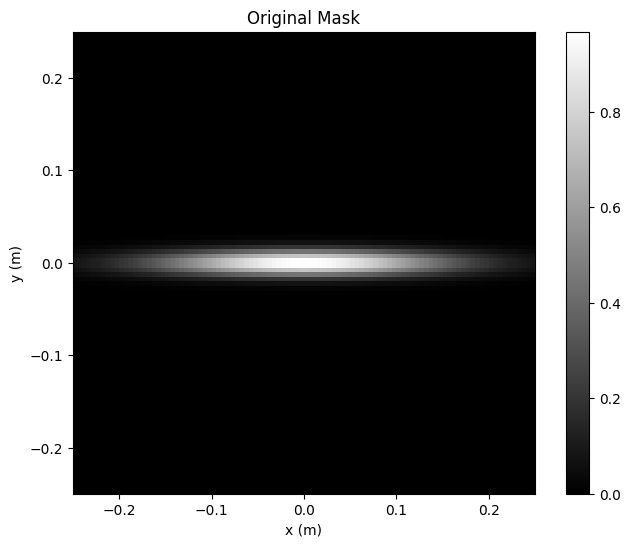

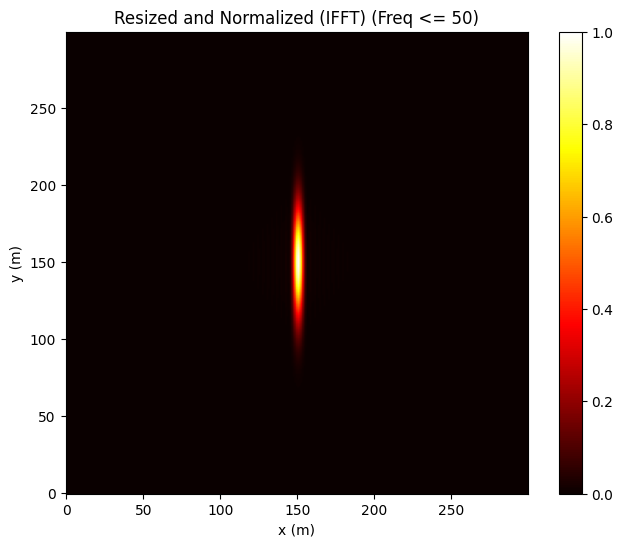

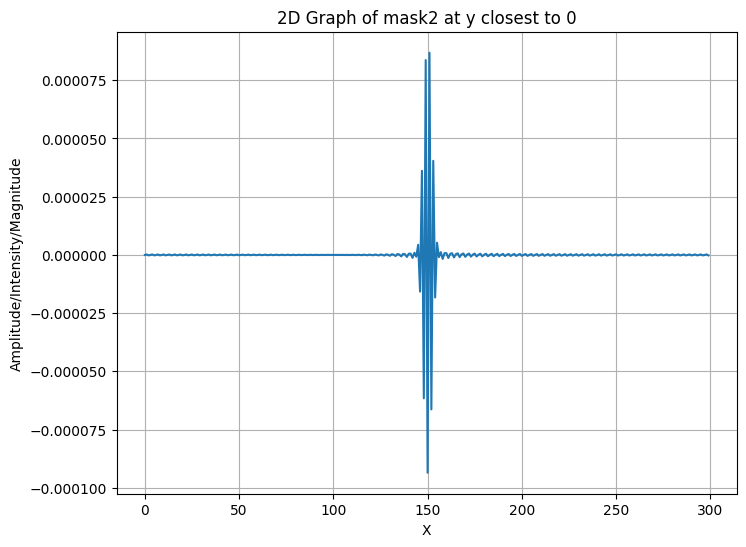

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift, fftfreq
from skimage.transform import resize

# ゾーンプレートのグリッド
plate_radius = 0.25
plate_grid_size = 100
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# Initialize the mask with zeros, same shape as X.
mask = np.zeros_like(X, dtype=float)  # dtype=float で初期化
# Set the mask to 1 where X is in the range 10 to 15 or -10 to -15.
#mask[(X >= -1*plate_radius*0.4) & (X <=plate_radius*0.4)&(Y >= -1*plate_radius*0.1) & (Y <= plate_radius*0.1)] = 1
mask=np.exp(-40*(1*X**2+128*Y**2))



# 標本点の0を1000個追加 (パディング)
padding_size = 100  # 各辺に500個ずつパディング (合計1000個)
mask_padded = np.pad(mask, padding_size, mode='constant', constant_values=0)



# Perform the 2D Inverse Fourier transform
#fourier_transform = fft2(mask)

# Perform the 2D Inverse Fourier transform
fourier_transform = fft2(mask_padded)


# Shift the zero frequency component to the center of the spectrum
fourier_transform_shifted = fftshift(fourier_transform)

# padded array size
padded_size = plate_grid_size + 2 * padding_size

# Calculate frequency axes for the padded array
freq_x_padded = fftshift(fftfreq(padded_size, d=x[1]-x[0]))
freq_y_padded = fftshift(fftfreq(padded_size, d=y[1]-y[0]))

# Create a grid for frequency values for the padded array
freq_X_padded, freq_Y_padded = np.meshgrid(freq_x_padded, freq_y_padded)

# Create a mask for frequencies <= 100 for the padded array
frequency_mask_padded = (np.abs(freq_X_padded) <= 1000) & (np.abs(freq_Y_padded) <= 1000)

# Apply the frequency mask to the padded fourier transform
masked_fourier_transform = np.where(frequency_mask_padded, fourier_transform_shifted, 0)


# Select the portion of the masked fourier transform
zoomed_fourier_transform = masked_fourier_transform[indices_y[0]:indices_y[-1]+1, indices_x[0]:indices_x[-1]+1]

# Resize zoomed_fourier_transform to the size of the original mask
#mask2 = resize(np.abs(zoomed_fourier_transform), (plate_grid_size, plate_grid_size), order=3, mode='reflect', anti_aliasing=True).real
mask2 = masked_fourier_transform#zoomed_fourier_transform
# Normalize the resized data to a maximum of 1
mask2 = (mask2 / np.max(np.abs(mask2)) )


# Display the original mask
plt.figure(figsize=(8, 6))
plt.imshow(mask, cmap='gray', origin='lower', extent=[-plate_radius, plate_radius, -plate_radius, plate_radius])
plt.title("Original Mask")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.show()

# Display the resized and normalized data
plt.figure(figsize=(8, 6))
plt.imshow(np.abs(mask2), cmap='hot', origin='lower')

plt.title("Resized and Normalized (IFFT) (Freq <= 50)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.show()

# Find the index closest to y=0
y_index = np.argmin(np.abs(y))

# Extract the data along y closest to 0
mask2_at_y0 = mask2[y_index, :]
#mask2_at_y0 = mask2[0, :]

# Create the 2D plot
plt.figure(figsize=(8, 6))
plt.plot(mask2_at_y0)
plt.title("2D Graph of mask2 at y closest to 0")
plt.xlabel("X")
plt.ylabel("Amplitude/Intensity/Magnitude")
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定数
wavelength = 0.01  # 波長 λ = 1cm
focal_length = 10  # 焦点距離 5m

plate_radius = 0.25  # ゾーンプレートの半径 (m)
plate_grid_size = 100  # ゾーンプレートの解像度

observation_plane = 10 # 観測面 z = 4m
observation_radius = plate_radius*10
observation_grid_size = 100


k = 2 * np.pi / wavelength  # 波数

# ゾーンプレートのグリッド
x = np.linspace(-plate_radius, plate_radius, plate_grid_size)
y = np.linspace(-plate_radius, plate_radius, plate_grid_size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)


# Initialize the mask with zeros, same shape as X.
mask = np.zeros_like(X, dtype=int)
# Set the mask to 1 where X is in the range 10 to 15 or -10 to -15.
#mask[(X >= -1*plate_radius*0.1) & (X <=plate_radius*0.1)&(Y >= -1*plate_radius*0.8) & (Y <= plate_radius*0.8)] = 1
#mask[R <= plate_radius * 0.25] = 1



# 位相変調（フレネル位相）

sa= -1
sb= -1
#sa=0
#sb=0


phase = k * (np.sqrt(sa*X**2 + sb*Y**2 + focal_length**2) - focal_length)

# ゾーンプレートの振幅分布（位相変調を振幅に適用）
#zone_amplitude = np.exp(1j * phase * (-1))
#zone_amplitude = np.exp(1j * phase * (-0.5))
#zone_amplitude = np.exp(1j * phase * (0))
#zone_amplitude = np.exp(1j * phase * (1))
#zone_amplitude = np.exp(1j * phase * (2))

#s_param=2
#zone_amplitude = np.exp(1j * phase * (s_param))
#zone_amplitude = np.exp(1j * phase)

#zone_amplitude = np.exp(1j * phase)*mask
zone_amplitude = np.exp(1j * phase)*abs(mask2)

# 観測平面のグリッド

obs_x = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_y = np.linspace(-observation_radius, observation_radius, observation_grid_size)
obs_X, obs_Y = np.meshgrid(obs_x, obs_y)

# 観測平面での振幅計算
field = np.zeros_like(obs_X, dtype=complex)

# ゾーンプレートの各点から観測平面への波の寄与を計算
for i in range(plate_grid_size):
    for j in range(plate_grid_size):
        # ゾーンプレート上の座標
        source_x = X[i, j]
        source_y = Y[i, j]
        source_z = 0  # ゾーンプレート面は z=0

        # 観測平面までの距離
        r = np.sqrt((obs_X - source_x)**2 + (obs_Y - source_y)**2 + observation_plane**2)

        # 観測平面での振幅累積
        field += zone_amplitude[i, j] * np.exp(1j * k * r) / r

# パワー分布（強度）
intensity = np.abs(field)**2

# パワー分布の描画
plt.imshow(intensity, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hot', origin='upper')
plt.colorbar(label="Intensity")
plt.title("Power Distribution with Phase Modulation (Direct Calculation)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()


# 位相

r2=(obs_X**2 + obs_Y**2)

#phase_image = np.angle(field)  # Calculate the phase of the field
phase_image = np.angle(field * np.exp(-1j * k * r2/(2*observation_plane)))  # Calculate the phase of the field

#  Phase
plt.figure(figsize=(8, 6))
plt.imshow(phase_image, extent=(-observation_radius, observation_radius, -observation_radius, observation_radius), cmap='hsv', origin='upper')  # Use 'hsv' or another suitable colormap
plt.colorbar(label="Phase (radians)")
plt.title("Phase Distribution")
plt.xlabel("x (m)")
plt.ylabel("y (m)")

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

ValueError: operands could not be broadcast together with shapes (100,100) (1100,1100) 

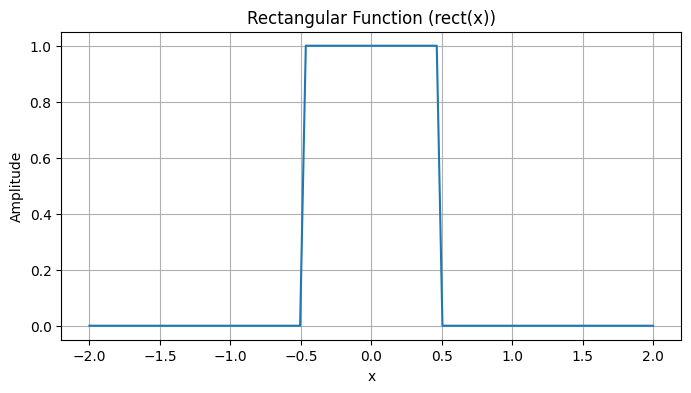

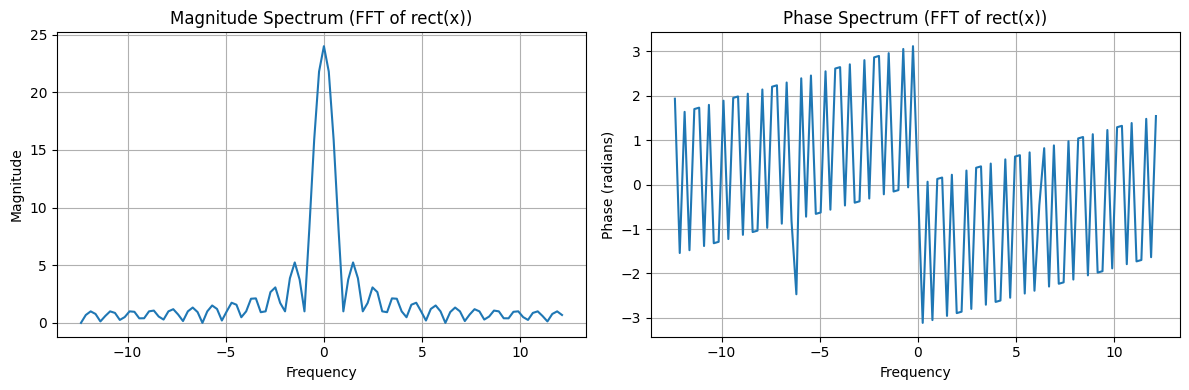

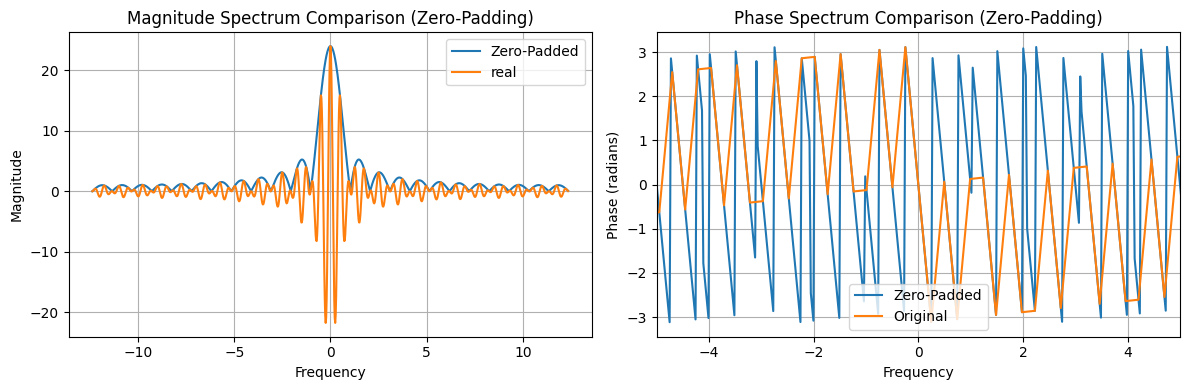

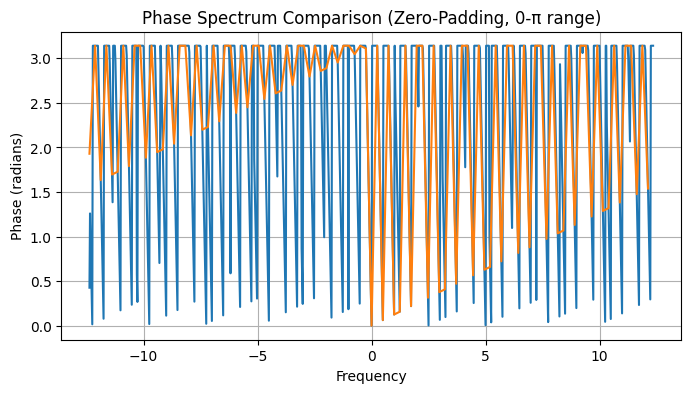

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftshift, fftfreq

# 1. Define the rect function and parameters
def rect(x, width=1):
    """Rectangular function."""
    return np.where(np.abs(x) <= width / 2, 1, 0)

N = 100  # Original signal length
width = 1  # Width of the rect function
x = np.linspace(-2, 2, N)  # x-axis values
signal = rect(x, width)  # The rect(x) signal

# 2. Plot the rect function
plt.figure(figsize=(8, 4))
plt.plot(x, signal)
plt.title("Rectangular Function (rect(x))")
plt.xlabel("x")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# 3. Perform FFT and plot results
# Calculate frequency values before shifting
frequencies = fftfreq(N, d=x[1] - x[0])
fft_values = fft(signal)  # FFT of the signal

# Shift both frequencies and fft_values
fft_shifted = fftshift(fft_values)
frequencies_shifted = fftshift(frequencies)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(frequencies_shifted, np.abs(fft_shifted))  # Magnitude spectrum
plt.title("Magnitude Spectrum (FFT of rect(x))")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(frequencies_shifted, np.angle(fft_shifted))  # Phase spectrum
plt.title("Phase Spectrum (FFT of rect(x))")
plt.xlabel("Frequency")
plt.ylabel("Phase (radians)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Zero-padding and comparison
padding_factor = 10
padded_signal = np.pad(signal, (0, (padding_factor - 1) * N), 'constant')

# Calculate frequency values before shifting for padded signal
padded_frequencies = fftfreq(len(padded_signal), d=x[1] - x[0])
padded_fft_values = fft(padded_signal)

# Shift both frequencies and fft_values for padded signal
padded_fft_shifted = fftshift(padded_fft_values)
padded_frequencies_shifted = fftshift(padded_frequencies)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(padded_frequencies_shifted, np.abs(padded_fft_shifted), label="Zero-Padded")
plt.plot(padded_frequencies_shifted, padded_fft_shifted.real, label="real")
#plt.plot(frequencies_shifted, np.abs(fft_shifted), label="Original")
plt.title("Magnitude Spectrum Comparison (Zero-Padding)")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(padded_frequencies_shifted, np.angle(padded_fft_shifted), label="Zero-Padded")
plt.plot(frequencies_shifted, np.angle(fft_shifted), label="Original")
plt.title("Phase Spectrum Comparison (Zero-Padding)")
plt.xlabel("Frequency")
plt.ylabel("Phase (radians)")
plt.legend()
plt.grid(True)
#plt.tight_layout()
#plt.show()


# Zoom-in settings (adjust these as needed)
zoom_freq_min = -5  # Lower frequency limit for zoom
zoom_freq_max = 5   # Upper frequency limit for zoom

# Set x-axis limits for zoom-in
plt.xlim(zoom_freq_min, zoom_freq_max)

plt.tight_layout()
plt.show()

# Phase spectrum comparison with adjustment and range restriction
plt.figure(figsize=(8, 4))

# Adjust phase of padded signal to 0-pi range
padded_phase_data = np.angle(padded_fft_shifted)
padded_phase_adjusted = np.where(padded_phase_data < 0, padded_phase_data + 2 * np.pi, padded_phase_data)
padded_phase_restricted = np.clip(padded_phase_adjusted, 0, np.pi)

plt.plot(padded_frequencies_shifted, padded_phase_restricted, label="Zero-Padded")

# Adjust phase of original signal to 0-pi range (same logic as before)
phase_data = np.angle(fft_shifted)
phase_adjusted = np.where(phase_data < 0, phase_data + 2 * np.pi, phase_data)
phase_restricted = np.clip(phase_adjusted, 0, np.pi)

plt.plot(frequencies_shifted, phase_restricted, label="Original")
plt.title("Phase Spectrum Comparison (Zero-Padding, 0-π range)")
plt.xlabel("Frequency")
plt.ylabel("Phase (radians)")
plt.grid(True)
# ... (zoom-in code remains the same) ...

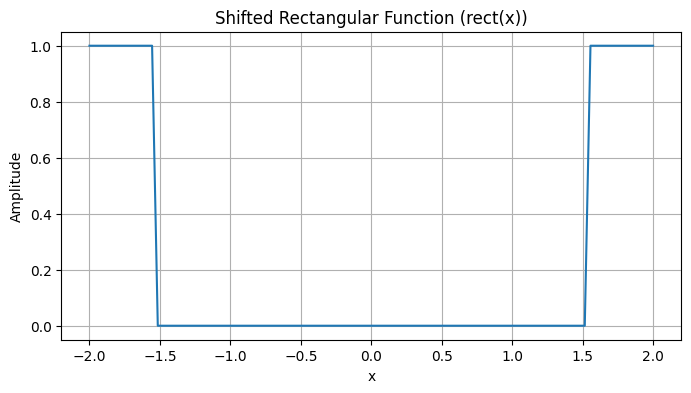

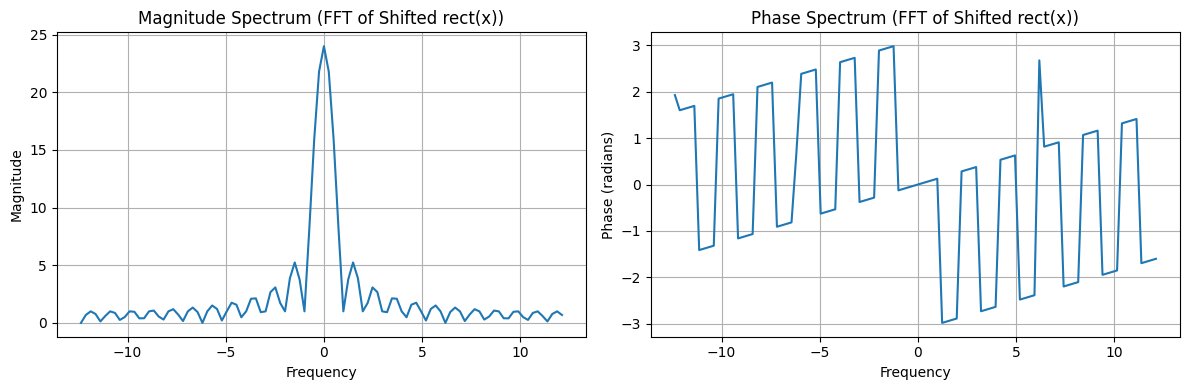

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftshift, fftfreq

# 1. Define the rect function and parameters
def rect(x, width=1):
    """Rectangular function."""
    return np.where(np.abs(x) <= width / 2, 1, 0)

N = 100  # Original signal length
width = 1  # Width of the rect function
x = np.linspace(-2, 2, N)  # x-axis values
signal = rect(x, width)  # The rect(x) signal

# 2. Shift the data:
# Calculate the shift amount (half the signal length)
shift_amount = N // 2

# Shift the signal to the left by the shift amount
# using numpy.roll
shifted_signal = np.roll(signal, -shift_amount)

# 3. Plot the shifted signal:
plt.figure(figsize=(8, 4))
plt.plot(x, shifted_signal)
plt.title("Shifted Rectangular Function (rect(x))")
plt.xlabel("x")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# 4. Perform FFT on the shifted signal:
frequencies = fftfreq(N, d=x[1] - x[0])
fft_values = fft(shifted_signal)

# Shift both frequencies and fft_values:
fft_shifted = fftshift(fft_values)
frequencies_shifted = fftshift(frequencies)

# 5. Plot the magnitude and phase spectra of the shifted signal:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(frequencies_shifted, np.abs(fft_shifted))  # Magnitude spectrum
plt.title("Magnitude Spectrum (FFT of Shifted rect(x))")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(frequencies_shifted, np.angle(fft_shifted))  # Phase spectrum
plt.title("Phase Spectrum (FFT of Shifted rect(x))")
plt.xlabel("Frequency")
plt.ylabel("Phase (radians)")
plt.grid(True)
plt.tight_layout()
plt.show()